# TP01 - Etapa 03: Classificação com MLP (TensorFlow/Keras)

**Objetivo:** Construir e treinar uma Rede Neural Profunda (MLP) para prever o status de confirmação de matrícula (`MATRICULA`) dos candidatos aprovados no SiSU.

## 0. Importação das Bibliotecas e Configuração Inicial

In [1]:

import mlflow
import mlflow.keras
from mlflow.models.signature import infer_signature
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from sklearn.ensemble import RandomForestClassifier

# Reprodutibilidade conforme a especificação do trabalho
np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1789751899.367111  944727 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789751899.368335  944727 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789751899.434260  944727 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789751901.412701  944727 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

## 1. Carregamento e Filtragem da Base

De acordo com a especificação:
- Base: `chamada_regular_sisu_2023_1.csv`
- Selecionar apenas candidatos aprovados na Chamada Regular (`APROVADO == 'S'`).
- Mapear `MATRICULA` (1 para `EFETIVADA` e 0 para `NÃO COMPARECEU`).

In [2]:
# Carregar a base de dados (Leva alguns segundos devido ao tamanho de >1GB do dataset)
print("Carregando a base de dados...")

# Obs: O separador é '|', a codificação é 'latin1' e os decimais usam vírgula (,)
df = pd.read_csv('../data/raw/chamada_regular_sisu_2023_1.csv', 
                 sep='|', 
                 encoding='latin1', 
                 decimal=',')

print(f"Foram carregados {df.shape[0]} registros.")
display(df)
df.head()

Carregando a base de dados...


/tmp/ipykernel_944727/734278499.py:5: DtypeWarning: Columns (0: TP_COTA) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/chamada_regular_sisu_2023_1.csv',


Foram carregados 2062815 registros.


,ANO,EDICAO,ETAPA,DS_ETAPA,CODIGO_IES,NOME_IES,SIGLA_IES,UF_IES,CODIGO_CAMPUS,NOME_CAMPUS,...,NOTA_L_COM_PESO,NOTA_CH_COM_PESO,NOTA_CN_COM_PESO,NOTA_M_COM_PESO,NOTA_R_COM_PESO,NOTA_CANDIDATO,NOTA_CORTE,CLASSIFICACAO,APROVADO,MATRICULA
0,2023,1,4,CHAMADA REGULAR,593,CENTRO FEDERAL DE EDUCAÇÃO TECNOLÓGICA CELSO S...,CEFET/RJ,RJ,1663,CEFET-RJ - MARIA DA GRAÇA,...,601.3,605.3,1230.6,2652.8,2760,713.64,728.60,32.0,N,PENDENTE
1,2023,1,4,CHAMADA REGULAR,593,CENTRO FEDERAL DE EDUCAÇÃO TECNOLÓGICA CELSO S...,CEFET/RJ,RJ,1663,CEFET-RJ - MARIA DA GRAÇA,...,545.2,554.5,1108.2,2206.4,1440,532.21,728.60,174.0,N,PENDENTE
2,2023,1,4,CHAMADA REGULAR,593,CENTRO FEDERAL DE EDUCAÇÃO TECNOLÓGICA CELSO S...,CEFET/RJ,RJ,1663,CEFET-RJ - MARIA DA GRAÇA,...,593.5,645.9,1246.8,2878.8,2580,722.27,728.60,19.0,N,PENDENTE
3,2023,1,4,CHAMADA REGULAR,593,CENTRO FEDERAL DE EDUCAÇÃO TECNOLÓGICA CELSO S...,CEFET/RJ,RJ,1663,CEFET-RJ - MARIA DA GRAÇA,...,485.1,572.2,1052.4,2082.4,1800,544.74,728.60,169.0,N,PENDENTE
4,2023,1,4,CHAMADA REGULAR,593,CENTRO FEDERAL DE EDUCAÇÃO TECNOLÓGICA CELSO S...,CEFET/RJ,RJ,1663,CEFET-RJ - MARIA DA GRAÇA,...,631.3,604.8,1242.2,2692.4,1740,628.25,728.60,127.0,N,PENDENTE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2062810,2023,1,4,CHAMADA REGULAR,588,UNIVERSIDADE TECNOLÓGICA FEDERAL DO PARANÁ,UTFPR,PR,1030843,CÂMPUS TOLEDO,...,568.6,521.4,1095.6,2303.2,800,587.64,607.46,9.0,N,PENDENTE
2062811,2023,1,4,CHAMADA REGULAR,588,UNIVERSIDADE TECNOLÓGICA FEDERAL DO PARANÁ,UTFPR,PR,1030843,CÂMPUS TOLEDO,...,537.9,467.7,916.4,1998.0,580,500.00,607.46,18.0,N,PENDENTE
2062812,2023,1,4,CHAMADA REGULAR,588,UNIVERSIDADE TECNOLÓGICA FEDERAL DO PARANÁ,UTFPR,PR,1030843,CÂMPUS TOLEDO,...,583.9,558.6,1091.6,2694.0,360,587.57,607.46,10.0,N,PENDENTE
2062813,2023,1,4,CHAMADA REGULAR,588,UNIVERSIDADE TECNOLÓGICA FEDERAL DO PARANÁ,UTFPR,PR,1030843,CÂMPUS TOLEDO,...,553.5,522.6,862.2,1647.6,520,456.21,607.46,21.0,N,PENDENTE


,ANO,EDICAO,ETAPA,DS_ETAPA,CODIGO_IES,NOME_IES,SIGLA_IES,UF_IES,CODIGO_CAMPUS,NOME_CAMPUS,...,NOTA_L_COM_PESO,NOTA_CH_COM_PESO,NOTA_CN_COM_PESO,NOTA_M_COM_PESO,NOTA_R_COM_PESO,NOTA_CANDIDATO,NOTA_CORTE,CLASSIFICACAO,APROVADO,MATRICULA
0,2023,1,4,CHAMADA REGULAR,593,CENTRO FEDERAL DE EDUCAÇÃO TECNOLÓGICA CELSO S...,CEFET/RJ,RJ,1663,CEFET-RJ - MARIA DA GRAÇA,...,601.3,605.3,1230.6,2652.8,2760,713.64,728.6,32.0,N,PENDENTE
1,2023,1,4,CHAMADA REGULAR,593,CENTRO FEDERAL DE EDUCAÇÃO TECNOLÓGICA CELSO S...,CEFET/RJ,RJ,1663,CEFET-RJ - MARIA DA GRAÇA,...,545.2,554.5,1108.2,2206.4,1440,532.21,728.6,174.0,N,PENDENTE
2,2023,1,4,CHAMADA REGULAR,593,CENTRO FEDERAL DE EDUCAÇÃO TECNOLÓGICA CELSO S...,CEFET/RJ,RJ,1663,CEFET-RJ - MARIA DA GRAÇA,...,593.5,645.9,1246.8,2878.8,2580,722.27,728.6,19.0,N,PENDENTE
3,2023,1,4,CHAMADA REGULAR,593,CENTRO FEDERAL DE EDUCAÇÃO TECNOLÓGICA CELSO S...,CEFET/RJ,RJ,1663,CEFET-RJ - MARIA DA GRAÇA,...,485.1,572.2,1052.4,2082.4,1800,544.74,728.6,169.0,N,PENDENTE
4,2023,1,4,CHAMADA REGULAR,593,CENTRO FEDERAL DE EDUCAÇÃO TECNOLÓGICA CELSO S...,CEFET/RJ,RJ,1663,CEFET-RJ - MARIA DA GRAÇA,...,631.3,604.8,1242.2,2692.4,1740,628.25,728.6,127.0,N,PENDENTE


### 1.1 Análise Exploratória Rápida (EDA) e Listagem de Colunas

Abaixo listamos todas as colunas para compreender a estrutura dos dados antes de selecionar os atributos da rede neural.

In [3]:
print("Quantidade de Colunas:", len(df.columns))
print("\nLista Completa de Colunas:")
print(list(df.columns))

print("\nResumo de Informações (Tipos e Valores Nulos):")
df.info(show_counts=True)

Quantidade de Colunas: 56

Lista Completa de Colunas:
['ANO', 'EDICAO', 'ETAPA', 'DS_ETAPA', 'CODIGO_IES', 'NOME_IES', 'SIGLA_IES', 'UF_IES', 'CODIGO_CAMPUS', 'NOME_CAMPUS', 'UF_CAMPUS', 'MUNICIPIO_CAMPUS', 'CODIGO_CURSO', 'NOME_CURSO', 'GRAU', 'TURNO', 'DS_PERIODICIDADE', 'TP_COTA', 'TIPO_MOD_CONCORRENCIA', 'MOD_CONCORRENCIA', 'QT_VAGAS_CONCORRENCIA', 'PERCENTUAL_BONUS', 'PESO_L', 'PESO_CH', 'PESO_CN', 'PESO_M', 'PESO_R', 'NOTA_MINIMA_L', 'NOTA_MINIMA_CH', 'NOTA_MINIMA_CN', 'NOTA_MINIMA_M', 'NOTA_MINIMA_R', 'MEDIA_MINIMA', 'CPF', 'INSCRICAO_ENEM', 'INSCRITO', 'SEXO', 'DT_NASCIMENTO', 'UF_CANDIDATO', 'MUNICIPIO_CANDIDATO', 'OPCAO', 'NOTA_L', 'NOTA_CH', 'NOTA_CN', 'NOTA_M', 'NOTA_R', 'NOTA_L_COM_PESO', 'NOTA_CH_COM_PESO', 'NOTA_CN_COM_PESO', 'NOTA_M_COM_PESO', 'NOTA_R_COM_PESO', 'NOTA_CANDIDATO', 'NOTA_CORTE', 'CLASSIFICACAO', 'APROVADO', 'MATRICULA']

Resumo de Informações (Tipos e Valores Nulos):
<class 'pandas.DataFrame'>
RangeIndex: 2062815 entries, 0 to 2062814
Data columns (total 

### 1.2 Análise de Valores Únicos / Repetidos por Coluna

Este trecho conta quantos valores únicos existem em cada coluna e exibe a contagem dos 5 valores que mais se repetem. Ajuste a base analisada (ex: `df` completo ou `df_aprovados`) de acordo com sua necessidade.

In [4]:
print("Análise de Valores Repetidos (Top 5 Mais Frequentes) na base COMPLETA:\n")

for col in df.columns:
    unique_count = df[col].nunique()
    print(f"=== Coluna: {col} ===")
    print(f"Quantidade de valores únicos distintos: {unique_count}")
    
    # Mostra os 5 termos que mais se repetem para não poluir muito a tela
    if unique_count > 0:
        print("Valores que mais se repetem (Top 5):")
        print(df[col].value_counts(dropna=False).head(5).to_string())
    print("-" * 40)


Análise de Valores Repetidos (Top 5 Mais Frequentes) na base COMPLETA:

=== Coluna: ANO ===
Quantidade de valores únicos distintos: 1
Valores que mais se repetem (Top 5):
ANO
2023    2062815
----------------------------------------
=== Coluna: EDICAO ===
Quantidade de valores únicos distintos: 1
Valores que mais se repetem (Top 5):
EDICAO
1    2062815
----------------------------------------
=== Coluna: ETAPA ===
Quantidade de valores únicos distintos: 1
Valores que mais se repetem (Top 5):
ETAPA
4    2062815
----------------------------------------
=== Coluna: DS_ETAPA ===
Quantidade de valores únicos distintos: 1
Valores que mais se repetem (Top 5):
DS_ETAPA
CHAMADA REGULAR    2062815
----------------------------------------
=== Coluna: CODIGO_IES ===
Quantidade de valores únicos distintos: 128
Valores que mais se repetem (Top 5):
CODIGO_IES
575    93381
583    90677
586    77941
580    61027
578    56853
----------------------------------------
=== Coluna: NOME_IES ===
Quantidade de

### 1.3 Limpeza Inicial: Remoção de Colunas Constantes/Redundantes

Como notado na EDA, `ANO`, `EDICAO`, `ETAPA` e `DS_ETAPA` possuem valor único (ex: ano=2023, etapa=4, etc). Assim, não carregam valor preditivo para a rede e são excluídas imediatamente.

In [5]:
colunas_para_dropar = [
    'ANO', 'EDICAO', 'ETAPA', 'DS_ETAPA', # Constantes
    'CPF', 'INSCRICAO_ENEM', 'INSCRITO', # Pessoais e Ímpar
    'CODIGO_IES', 'NOME_IES', 'CODIGO_CAMPUS', 'NOME_CAMPUS', 'CODIGO_CURSO', 'NOME_CURSO', # Nomes/Ids
    'NOTA_L_COM_PESO', 'NOTA_CH_COM_PESO', 'NOTA_CN_COM_PESO', 'NOTA_M_COM_PESO', 'NOTA_R_COM_PESO', # Variância duplicada
    'NOTA_MINIMA_L', 'NOTA_MINIMA_CH', 'NOTA_MINIMA_CN', 'NOTA_MINIMA_M', 'NOTA_MINIMA_R', 'MEDIA_MINIMA',
    'PESO_L', 'PESO_CH', 'PESO_CN', 'PESO_M', 'PESO_R'
]

# ============== NEW FEATURES ==============
# 1. Feature de IDADE_CANDIDATO
print("Gerando Idade do Candidato...")
df['DT_NASCIMENTO'] = pd.to_numeric(df['DT_NASCIMENTO'], errors='coerce')
df['IDADE_CANDIDATO'] = 2023 - df['DT_NASCIMENTO']
df['IDADE_CANDIDATO'].fillna(df['IDADE_CANDIDATO'].median(), inplace=True) # Tapar buraco p/ quem não declarou perfeitamente
colunas_para_dropar.append('DT_NASCIMENTO')

# 2. Feature de MARGEM_APROVACAO
print("Gerando Margem de Aprovação...")
# Forçar cast limpo caso Pandas não tenha pego decimal=; por causa de outliers de string
df['NOTA_CANDIDATO'] = pd.to_numeric(df['NOTA_CANDIDATO'].astype(str).str.replace(',', '.'), errors='coerce')
df['NOTA_CORTE'] = pd.to_numeric(df['NOTA_CORTE'].astype(str).str.replace(',', '.'), errors='coerce')
df['MARGEM_APROVACAO'] = df['NOTA_CANDIDATO'] - df['NOTA_CORTE']
df['MARGEM_APROVACAO'].fillna(0, inplace=True)
colunas_para_dropar.append('NOTA_CORTE') # Abstraído com sucesso

# ============== INSPIRADO NO TP02 ============== 
# 3. Feature: RAZAO_VAGAS (Classificação vs Fila)
print("Gerando Proporção de Vagas vs Ranking...")
df['CLASSIFICACAO'] = pd.to_numeric(df['CLASSIFICACAO'], errors='coerce')
df['QT_VAGAS_CONCORRENCIA'] = pd.to_numeric(df['QT_VAGAS_CONCORRENCIA'], errors='coerce')
df['RAZAO_VAGAS'] = df['CLASSIFICACAO'] / df['QT_VAGAS_CONCORRENCIA']
df['RAZAO_VAGAS'].fillna(df['RAZAO_VAGAS'].median(), inplace=True)
colunas_para_dropar.extend(['CLASSIFICACAO', 'QT_VAGAS_CONCORRENCIA']) # Substituídos

# 4. Feature: MESMA_UF (Morte de Alta Cardinalidade Regional)
df['MESMA_UF'] = (df['UF_CANDIDATO'] == df['UF_CAMPUS']).astype(int)
# As UFs serão dropadas adiante após calcularmos a distância geográfica!


# Limpeza de RAM
df.drop(columns=colunas_para_dropar, inplace=True, errors='ignore')
print(f"Foram removidas {len(colunas_para_dropar)} colunas e o dataset foi enriquecido!")


Gerando Idade do Candidato...
Gerando Margem de Aprovação...


/tmp/ipykernel_944727/116156853.py:15: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['IDADE_CANDIDATO'].fillna(df['IDADE_CANDIDATO'].median(), inplace=True) # Tapar buraco p/ quem não declarou perfeitamente


Gerando Proporção de Vagas vs Ranking...
Foram removidas 33 colunas e o dataset foi enriquecido!


/tmp/ipykernel_944727/116156853.py:24: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['MARGEM_APROVACAO'].fillna(0, inplace=True)
/tmp/ipykernel_944727/116156853.py:33: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works 

In [6]:
# Filtragem: Selecionar apenas quem foi aprovado
df_aprovados = df[df['APROVADO'] == 'S'].copy()

# Manter apenas as duas classes listadas na documentação do trabalho
classes_validas = ['EFETIVADA', 'NÃO COMPARECEU']
df_aprovados = df_aprovados[df_aprovados['MATRICULA'].isin(classes_validas)].copy()

# Criar o target binário como exigido: 1 ('EFETIVADA') e 0 ('NÃO COMPARECEU')
df_aprovados['MATRICULA_TARGET'] = df_aprovados['MATRICULA'].map({'EFETIVADA': 1, 'NÃO COMPARECEU': 0})

print(f"Número de candidatos aprovados mantidos para classificação: {df_aprovados.shape[0]}")
print("\nDistribuição do Target (MATRICULA_TARGET):")
print(df_aprovados['MATRICULA_TARGET'].value_counts(normalize=True))

Número de candidatos aprovados mantidos para classificação: 205530

Distribuição do Target (MATRICULA_TARGET):
MATRICULA_TARGET
0    0.504768
1    0.495232
Name: proportion, dtype: float64


## 2. Engenharia de Atributos e Pré-processamento

- **One-Hot Encoding**: Variáveis categóricas (`SEXO`, `TURNO`, `MOD_CONCORRENCIA`, `OPCAO`).
- **Padronização**: Variáveis numéricas (notas) usando `StandardScaler`.

### 2.1 Engenharia de Atributos: Distância Candidato vs Campus

Nesta sub-etapa inovadora, cruzaremos os municípios do candidato e da universidade com a base do IBGE para encontrar a distância espacial em Kilômetros (fórmula de Haversine). Este é um indicador poderoso de mobilidade acadêmica.

In [7]:
# --- Criação da Feature: Distância do Candidato até o Campus (em km) ---
print("Acessando base de coordenadas do IBGE e mesclando com o SiSU...")

url_mun = "https://raw.githubusercontent.com/kelvins/Municipios-Brasileiros/main/csv/municipios.csv"
url_est = "https://raw.githubusercontent.com/kelvins/Municipios-Brasileiros/main/csv/estados.csv"

df_mun = pd.read_csv(url_mun)
df_est = pd.read_csv(url_est)

# Acoplamento IBGE
df_geo = df_mun.merge(df_est[['codigo_uf', 'uf']], on='codigo_uf')
df_geo['nome_upper'] = df_geo['nome'].str.upper().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

# Padronização local
df_aprovados['MUN_CANDIDATO_NORM'] = df_aprovados['MUNICIPIO_CANDIDATO'].str.upper().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')
df_aprovados['MUN_CAMPUS_NORM'] = df_aprovados['MUNICIPIO_CAMPUS'].str.upper().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

# Merge - Candidato
df_aprovados = df_aprovados.merge(
    df_geo[['nome_upper', 'uf', 'latitude', 'longitude']], 
    left_on=['MUN_CANDIDATO_NORM', 'UF_CANDIDATO'], 
    right_on=['nome_upper', 'uf'], 
    how='left'
).rename(columns={'latitude': 'LAT_CANDIDATO', 'longitude': 'LON_CANDIDATO'})

# Merge - Campus
df_aprovados = df_aprovados.merge(
    df_geo[['nome_upper', 'uf', 'latitude', 'longitude']], 
    left_on=['MUN_CAMPUS_NORM', 'UF_IES'], 
    right_on=['nome_upper', 'uf'], 
    how='left'
).rename(columns={'latitude': 'LAT_CAMPUS', 'longitude': 'LON_CAMPUS'})

# Fórmula vetorial Matemática (Haversine)
def haversine_vectorized(lat1, lon1, lat2, lon2):
    import numpy as np
    lat1, lon1, lat2, lon2 = np.radians([lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c # Raio terra

df_aprovados['DISTANCIA_CAMPUS_KM'] = haversine_vectorized(
    df_aprovados['LAT_CANDIDATO'], df_aprovados['LON_CANDIDATO'],
    df_aprovados['LAT_CAMPUS'], df_aprovados['LON_CAMPUS']
)

# Preenchimento seguro onde falhar
df_aprovados['DISTANCIA_CAMPUS_KM'] = df_aprovados['DISTANCIA_CAMPUS_KM'].fillna(df_aprovados['DISTANCIA_CAMPUS_KM'].mean())

colunas_limpeza = ['MUN_CANDIDATO_NORM', 'MUN_CAMPUS_NORM', 'nome_upper_x', 'uf_x', 'nome_upper_y', 'uf_y', 'LAT_CANDIDATO', 'LON_CANDIDATO', 'LAT_CAMPUS', 'LON_CAMPUS', 'UF_CANDIDATO', 'UF_CAMPUS', 'UF_IES', 'MUNICIPIO_CANDIDATO', 'MUNICIPIO_CAMPUS']
df_aprovados.drop(columns=[c for c in colunas_limpeza if c in df_aprovados.columns], inplace=True)

print("\nNova feature numérica 'DISTANCIA_CAMPUS_KM' injetada!")
print(df_aprovados[['DISTANCIA_CAMPUS_KM']].head(10))


Acessando base de coordenadas do IBGE e mesclando com o SiSU...

Nova feature numérica 'DISTANCIA_CAMPUS_KM' injetada!
   DISTANCIA_CAMPUS_KM
0             0.000000
1            17.737529
2            16.981935
3             0.000000
4            21.320872
5             0.000000
6            10.460705
7             0.000000
8           456.216416
9            17.737529


In [8]:
# Definir atributos (Features e Target)
features_categoricas = ['SEXO', 'TURNO', 'GRAU', 'TIPO_MOD_CONCORRENCIA', 'OPCAO'] # GRAU (Bacharel, Licenciatura) e TIPO agrupado
features_numericas = ['NOTA_L', 'NOTA_CH', 'NOTA_CN', 'NOTA_M', 'NOTA_R', 'DISTANCIA_CAMPUS_KM', 'IDADE_CANDIDATO', 'MARGEM_APROVACAO', 'RAZAO_VAGAS', 'MESMA_UF']
# Algumas notas podem vir vazio/NaN dependo do arquivo, preenchemos com 0
df_aprovados[features_numericas] = df_aprovados[features_numericas].fillna(0)
df_aprovados[features_categoricas] = df_aprovados[features_categoricas].fillna('Indefinido') # Previne erros no Categorical Encoder
display(df_aprovados)
X = df_aprovados[features_categoricas + features_numericas]
y = df_aprovados['MATRICULA_TARGET']
# Separar treino e teste usando validação cruzada simples (holdout de 20%) estratificado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Construir Processador Coluna por Coluna. 
# 'sparse_threshold=0' garante a geração de NumPy arrays densos (obrigatório pro fit sequencial Keras)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_categoricas)
    ],
    sparse_threshold=0
)
# Rodar transformações
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print(f"Shape dos dados de Treino Transformados: {X_train_processed.shape}")
print(f"Shape dos dados de Teste Transformados: {X_test_processed.shape}")


,SIGLA_IES,GRAU,TURNO,DS_PERIODICIDADE,TP_COTA,TIPO_MOD_CONCORRENCIA,MOD_CONCORRENCIA,PERCENTUAL_BONUS,SEXO,OPCAO,...,NOTA_R,NOTA_CANDIDATO,APROVADO,MATRICULA,IDADE_CANDIDATO,MARGEM_APROVACAO,RAZAO_VAGAS,MESMA_UF,MATRICULA_TARGET,DISTANCIA_CAMPUS_KM
0,CEFET/RJ,Bacharelado,Noturno,Semestral,NaN,A,Ampla concorrência,NaN,M,1,...,940,755.80,S,NÃO COMPARECEU,20,27.20,0.133333,1,0,0.000000
1,CEFET/RJ,Bacharelado,Noturno,Semestral,NaN,A,Ampla concorrência,NaN,M,1,...,840,730.31,S,NÃO COMPARECEU,23,1.71,0.866667,1,0,17.737529
2,CEFET/RJ,Bacharelado,Noturno,Semestral,NaN,A,Ampla concorrência,NaN,M,1,...,920,732.29,S,NÃO COMPARECEU,19,3.69,0.666667,1,0,16.981935
3,CEFET/RJ,Bacharelado,Noturno,Semestral,NaN,A,Ampla concorrência,NaN,M,2,...,920,734.79,S,NÃO COMPARECEU,18,6.19,0.533333,1,0,0.000000
4,CEFET/RJ,Bacharelado,Noturno,Semestral,NaN,A,Ampla concorrência,NaN,M,2,...,860,731.55,S,NÃO COMPARECEU,18,2.95,0.800000,1,0,21.320872
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205525,UTFPR,Tecnológico,Noturno,Semestral,D,L,"Candidatos que, independentemente da renda (ar...",NaN,M,1,...,540,609.61,S,EFETIVADA,20,2.15,0.666667,1,1,0.000000
205526,UTFPR,Tecnológico,Noturno,Semestral,D,L,"Candidatos que, independentemente da renda (ar...",NaN,M,2,...,560,678.71,S,EFETIVADA,39,71.25,0.166667,1,1,0.000000
205527,UTFPR,Tecnológico,Noturno,Semestral,D,L,"Candidatos que, independentemente da renda (ar...",NaN,M,2,...,600,609.39,S,EFETIVADA,17,1.93,0.833333,1,1,0.000000
205528,UTFPR,Tecnológico,Noturno,Semestral,D,L,"Candidatos que, independentemente da renda (ar...",NaN,M,1,...,740,610.24,S,NÃO COMPARECEU,18,2.78,0.500000,1,0,52.285650


Shape dos dados de Treino Transformados: (164424, 27)
Shape dos dados de Teste Transformados: (41106, 27)


## 3. & 4. Construção da Arquitetura MLP, Treinamento e Rastreamento (MLflow)

Nesta etapa integramos a definição do MLflow e o ciclo de Treinamento e Avaliação da Rede MLP obedecendo aos critérios do documento:
- 1 a 2 camadas com `ReLU` e Output com `Sigmoide`
- Callback (EarlyStopping) e Dropout (Regularização)
- Optimizer Adam, `binary_crossentropy`.
- **MLflow**: Rastreamento de métricas, parâmetros, matriz de confusão e curvas de aprendizado.
- Salva automaticamente o modelo no MLflow se ele for o possuir o **melhor AUC** até o momento.

In [9]:
# Configuração do Experimento no MLflow
experiment_name = "TP01_MLP_SiSU_Classificacao"
mlflow.set_experiment(experiment_name)

# Desativar autolog padrão do tensorflow para termos o controle fino de salvar apenas modelos melhores e plotar os graficos exigidos
mlflow.tensorflow.autolog(disable=True) 


In [10]:
def evaluate_and_log_plots(history, model, X_test, y_test, y_pred_prob, optimal_threshold):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import os
    import mlflow
    from sklearn.metrics import confusion_matrix

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Curvas de Aprendizado (Loss)
    axes[0].plot(history.history['loss'], label='Treino Loss', color='darkred')
    axes[0].plot(history.history['val_loss'], label='Val Loss', color='lightcoral')
    axes[0].set_title('Custo (Loss)')
    axes[0].set_xlabel('Épocas')
    axes[0].legend()

    # 2. Curvas de Aprendizado (AUC)
    axes[1].plot(history.history['auc'], label='Treino AUC', color='darkblue')
    axes[1].plot(history.history['val_auc'], label='Val AUC', color='cornflowerblue')
    axes[1].set_title('Histórico AUC')
    axes[1].set_xlabel('Épocas')
    axes[1].legend()

    # Opt Threshold Cut
    y_pred_opt = (y_pred_prob >= optimal_threshold).astype(int)

    # 3. Matriz de Confusão Otimizada
    sns.heatmap(confusion_matrix(y_test, y_pred_opt), annot=True, fmt='d', cmap='Blues', ax=axes[2], 
                xticklabels=['NÃO COMPARECEU', 'EFETIVADA'], 
                yticklabels=['NÃO COMPARECEU', 'EFETIVADA'])
    axes[2].set_title(f'Confusão (Corte={optimal_threshold:.2f})')
    axes[2].set_ylabel('Real')
    axes[2].set_xlabel('Predito')

    plt.tight_layout()
    plt.savefig("metricas_mlp.png")
    mlflow.log_artifact("metricas_mlp.png")
    plt.show()
    
    if os.path.exists("metricas_mlp.png"): os.remove("metricas_mlp.png")



In [11]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, roc_curve
import numpy as np

def run_mlp_experiment(hidden_layers=[128, 64, 32], dropout_rate=0.35, batch_size=512, epochs=70, learning_rate=0.0003, use_smote=True, run_name="MLP_SMOTE_Run"):
    with mlflow.start_run(run_name=run_name) as run:
        # ---- SMOTE vs CLASS WEIGHT BALANCING ----
        if use_smote:
            print("Aplicando SMOTE (Super-amostragem sintética da classe minoritária)...")
            try:
                from imblearn.over_sampling import SMOTE
                smote = SMOTE(random_state=42)
                X_train_final, y_train_final = smote.fit_resample(X_train_processed, y_train)
                class_weights_dict = None # Não precisa pesar a classe, o SMOTE já igualou a estatística
                print(f"Tamanho do Treino após SMOTE: {X_train_final.shape}")
            except ImportError:
                print("Aviso: 'imbalanced-learn' ausente. Retornando ao class_weights.")
                use_smote = False
                
        if not use_smote:
            X_train_final, y_train_final = X_train_processed, y_train
            cw = compute_class_weight('balanced', classes=np.unique(y_train_final), y=y_train_final)
            class_weights_dict = dict(enumerate(cw))
            print(f"Pesos de Classe Matemáticos: {class_weights_dict}")

        # ---- ARQUITETURA KERAS ----
        model = Sequential()
        model.add(Dense(hidden_layers[0], input_dim=X_train_final.shape[1]))
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Activation('relu'))
        model.add(Dropout(dropout_rate))
        
        for units in hidden_layers[1:]:
            model.add(Dense(units))
            model.add(tf.keras.layers.BatchNormalization())
            model.add(tf.keras.layers.Activation('relu'))
            model.add(Dropout(dropout_rate))
            
        model.add(Dense(1, activation='sigmoid'))
        
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
        model.compile(optimizer=opt, loss='binary_crossentropy',
                      metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Precision(name='precision')])
                      
        mlflow.log_params({
            "hidden_layers": str(hidden_layers),
            "dropout_rate": dropout_rate,
            "batch_size": batch_size,
            "epochs": epochs,
            "learning_rate": learning_rate,
            "usou_smote": use_smote
        })
        
        early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
        
        print(f"\nTreinando Deep Keras... ({run_name})")
        history = model.fit(X_train_final, y_train_final, epochs=epochs, batch_size=batch_size, 
                            validation_split=0.2, callbacks=[early_stop],
                            class_weight=class_weights_dict, verbose=1)
        
        # ---- THRESHOLD TUNING & ROC CURVE ----
        print("\nBuscando Ponto de Corte Otimizado com base na Curva ROC...")
        y_pred_prob = model.predict(X_test_processed).flatten()
        
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
        J = tpr - fpr # Youden's J statistic
        optimal_idx = np.argmax(J)
        optimal_threshold = thresholds[optimal_idx]
        
        print(f"Threshold Normalçado: 0.50 | Threshold Ótimo (Youden): {optimal_threshold:.4f}")
        y_pred_opt = (y_pred_prob >= optimal_threshold).astype(int)
        
        val_loss, val_acc, val_auc, val_prec = model.evaluate(X_test_processed, y_test, verbose=0)
        acc_otimizada = accuracy_score(y_test, y_pred_opt)
        
        mlflow.log_metric("test_accuracy_default", val_acc)
        mlflow.log_metric("test_accuracy_otimizada", acc_otimizada)
        mlflow.log_metric("test_auc", val_auc)
        mlflow.log_metric("optimal_threshold", optimal_threshold)
        
        print(f"\nMétricas (Corte 0.50):       Acurácia -> {val_acc:.4f} | AUC: {val_auc:.4f}")
        print(f"Métricas (Corte {optimal_threshold:.2f}):  Acurácia -> {acc_otimizada:.4f}\n")
        
        print("--- Classification Report (Corte Otimizado) ---")
        print(classification_report(y_test, y_pred_opt))
        
        evaluate_and_log_plots(history, model, X_test_processed, y_test, y_pred_prob, optimal_threshold)
        
        client = mlflow.tracking.MlflowClient()
        runs = client.search_runs(experiment_ids=[mlflow.get_experiment_by_name(experiment_name).experiment_id],
                                  order_by=["metrics.test_auc DESC"])
        best_auc_recorded = runs[0].data.metrics.get("test_auc", 0) if len(runs) > 1 else val_auc
        
        if val_auc >= best_auc_recorded or len(runs) == 1:
            print(f"🔥 NOVO RECORDE de AUC alcançado! Salvando o modelo no MLflow...")
            mlflow.keras.log_model(model, "mlp_best_model")
        
        return model, history, optimal_threshold



Aplicando SMOTE (Super-amostragem sintética da classe minoritária)...
Tamanho do Treino após SMOTE: (165992, 27)


/home/thiago/cd02/tp01/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1789751956.432377  944727 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



Treinando Deep Keras... (MLP_SMOTE_ROC)
Epoch 1/70
260/260 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.5615 - auc: 0.5866 - loss: 0.7273 - precision: 0.5550 - val_accuracy: 0.6242 - val_auc: 0.6722 - val_loss: 0.6477 - val_precision: 0.6079
Epoch 2/70
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5915 - auc: 0.6272 - loss: 0.6803 - precision: 0.5783 - val_accuracy: 0.6338 - val_auc: 0.6834 - val_loss: 0.6414 - val_precision: 0.6170
Epoch 3/70
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6041 - auc: 0.6447 - loss: 0.6650 - precision: 0.5891 - val_accuracy: 0.6390 - val_auc: 0.6895 - val_loss: 0.6369 - val_precision: 0.6249
Epoch 4/70
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6172 - auc: 0.6597 - loss: 0.6553 - precision: 0.6011 - val_accuracy: 0.6426 - val_auc: 0.6936 - val_loss: 0.6342 - val_precision: 0.6286
Epoch 5/70
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6227 - auc: 0.6685 - loss: 0.6494 - precision: 0.6071 - val_accuracy: 0.6456 

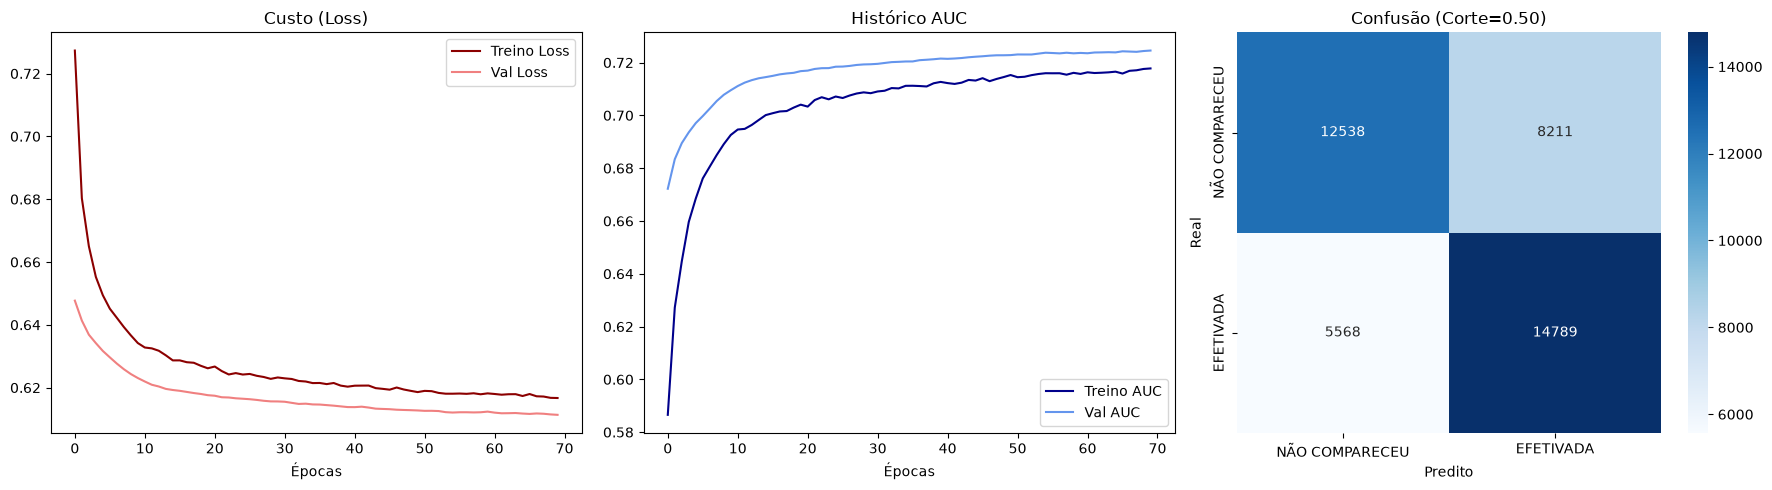

In [12]:
# Testando Keras com SMOTE e Threshold Tuning Automático
model_1, hist_1, opt_thresh = run_mlp_experiment(
    hidden_layers=[128, 64, 32],
    dropout_rate=0.35,
    epochs=70,
    learning_rate=0.0003,
    batch_size=512,
    use_smote=True,
    run_name="MLP_SMOTE_ROC"
)


### 4.3. Comparação com Modelo Clássico Baseline (Ex: Random Forest)

In [13]:
print("Treinando Algoritmo Baseline de Machine Learning Clássico (Random Forest)...")

# Treinamento do baseline
from sklearn.ensemble import RandomForestClassifier
baseline_rf = RandomForestClassifier(random_state=42, n_estimators=50, n_jobs=-1)
baseline_rf.fit(X_train_processed, y_train)

y_pred_rf = baseline_rf.predict(X_test_processed)

print("\n=== Relatório de Classificação: Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['NÃO COMPARECEU (0)', 'EFETIVADA (1)']))

# Resgatando as predições do Keras (variável model_1) que rodou no bloco do MLflow para comparar as acurácias:
y_pred_prob_mlp = model_1.predict(X_test_processed)
# Utilizando o Ponto de Corte Otimizado que salvamos
y_pred_mlp = (y_pred_prob_mlp >= opt_thresh).astype(int).flatten()

print("\n================ PONTUAÇÃO E COMPARATIVO FINAAAAAAAL =================")
print(f"Acurácia do Modelo Keras MLP (ROC Cut): {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"Acurácia do Random Forest (Baseline):    {accuracy_score(y_test, y_pred_rf):.4f}")


Treinando Algoritmo Baseline de Machine Learning Clássico (Random Forest)...

=== Relatório de Classificação: Random Forest ===
                    precision    recall  f1-score   support

NÃO COMPARECEU (0)       0.65      0.65      0.65     20749
     EFETIVADA (1)       0.65      0.65      0.65     20357

          accuracy                           0.65     41106
         macro avg       0.65      0.65      0.65     41106
      weighted avg       0.65      0.65      0.65     41106

1285/1285 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

================ PONTUAÇÃO E COMPARATIVO FINAAAAAAAL =================
Acurácia do Modelo Keras MLP (ROC Cut): 0.6648
Acurácia do Random Forest (Baseline):    0.6507


### 4.4. Interpretabilidade: O que mais pesa? (Feature Importances do Algoritmo Clássico)

Para responder à pergunta sobre abstração local (`SIGLA_IES`, distância, notas) e para não atirar no escuro com _black-box_, usamos a Entropia do nosso algoritmo Random Forest para listar as TOP Features que ditam o comparecimento!

Extraindo força de dezenas atributos processados...


/tmp/ipykernel_944727/2318401042.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso_Gini', y='Atributo', data=fi_df, palette='magma', ax=ax)


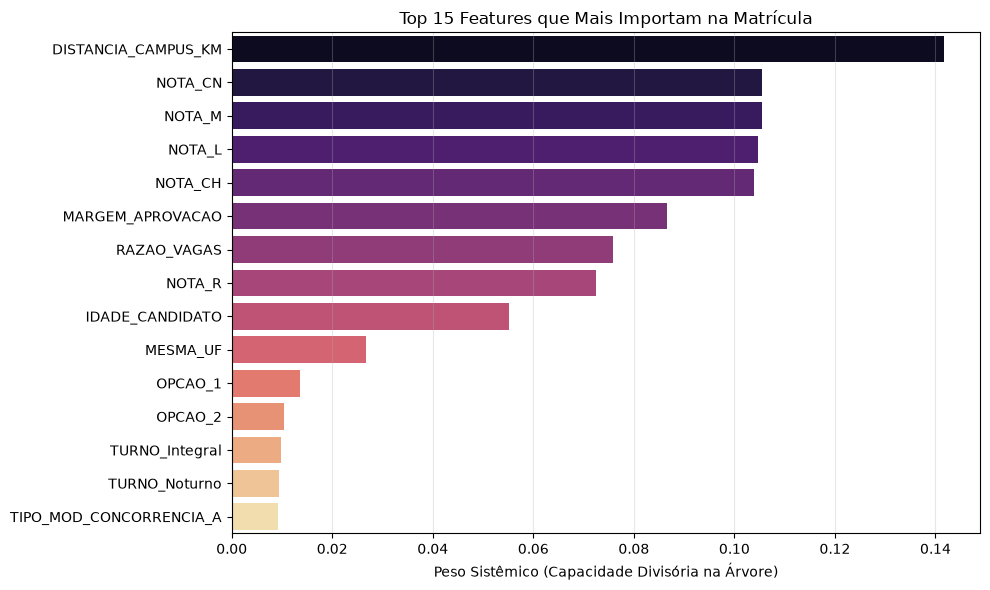

In [14]:
print("Extraindo força de dezenas atributos processados...")

try:
    # Compatível com Scikit Learn >= 1.0
    feature_names = preprocessor.get_feature_names_out()
    importances = baseline_rf.feature_importances_
    
    # Limpeza visual dos nomes (tira os afixos 'num__' ou 'cat__')
    clean_names = [f.replace('num__', '').replace('cat__', '') for f in feature_names]
    
    fi_df = pd.DataFrame({'Atributo': clean_names, 'Peso_Gini': importances})
    fi_df = fi_df.sort_values(by='Peso_Gini', ascending=False).head(15)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x='Peso_Gini', y='Atributo', data=fi_df, palette='magma', ax=ax)
    ax.set_title('Top 15 Features que Mais Importam na Matrícula')
    ax.set_xlabel('Peso Sistêmico (Capacidade Divisória na Árvore)')
    ax.set_ylabel('')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Erro de extração. O Scikit-learn pode não suportar get_feature_names_out:", e)
